# Hierarchical Clustering - UPGMA

---
## Learning Objectives

1. Implement a distance-based phylogeny neighbor joining algorithm
1. Understanding of hierarchical clustering
1. Manipulation of arrays and lists in Python


---
## Imports
You will need to install a two new packages to properly render your phylogenetic trees. Using your preferred package manager, install both [`biopython`](https://biopython.org/) and `matplotlib` into your virtual environments.

For example:
```bash
$ micromamba create -n module06 -c bioconda -c conda-forge python numpy matplotlib biopython
```

In [8]:
from typing import List, Tuple, Dict
from io import StringIO

import matplotlib.pyplot as plt
from Bio import Phylo
import numpy as np
import pandas as pd

INTERNALS = {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'}

---
## Background

Today we will implement a distance-based phylogenetic tree construction method using the Neighbor-Joining (NJ) algorithm and Smith-Waterman local alignment scores. Unlike UPGMA (Unweighted Pair Group Method using Arithmetic averages), NJ produces unrooted trees and does not assume a constant evolutionary rate across lineages, making it more biologically realistic for analyzing sequence relationships.

We will use HIV-1 reverse transcriptase sequences to construct our phylogenetic tree. The Smith-Waterman algorithm will be used to generate pairwise local alignment scores, which will then be converted into distances for tree construction. This approach is particularly suitable for HIV sequence analysis as it:
1. Handles sequence variations effectively through local alignment
2. Accounts for potential rate heterogeneity across different viral strains
3. Does not assume a molecular clock

The ultimate output will be an unrooted phylogenetic tree representing the evolutionary relationships between the HIV-1 sequences, visualized using the ete3 library. This method provides insights into viral diversity and evolutionary patterns while avoiding the assumptions of simpler hierarchical clustering approaches.

The key innovations of this implementation are:
- Use of Smith-Waterman for sensitive local alignment scoring
- Implementation of Neighbor-Joining for unrooted tree construction
- More biologically realistic evolutionary model

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

---
## Distance metrics for comparing sequences

### Smith-Waterman
This was previously implemented. Feel free to import if you know how...or Copy & Paste.



In [9]:
def read_fasta(filename: str = "data/lafayette_SARS_RT.fasta") -> Dict[str, str]:
    """Reads sequences from FASTA file.

    Args:
        filename (str): Path to FASTA file containing HIV RT sequences

    Returns:
        Dict[str, str]: Dictionary mapping sequence IDs to sequences

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> len(seqs) > 0
        True
    """
    seqs = {}
    with open(file=filename, mode='r', encoding='utf-8') as infile:
        for line in infile:
            curr_line = line.rstrip()
            if curr_line[0] == ">":
                head = curr_line.split(" ")
                head = head[-1]
                seqs[head] = ""
                print(f"Currently reading in Sequence: {head}", end="\r")
                continue
            seqs[head] += curr_line
    print("\nFinished reading!\n")
    return seqs
            

In [10]:
def cal_score(matrix, seq1, seq2, i, j, match, mismatch, gap):
    '''Calculate score for position (i,j) in scoring matrix, also record move to trace back
    
    Args:
        matrix (numpy array): scoring matrix
        seq1 (str): sequence 1
        seq2 (str): sequence 2
        i (int): current row number
        j (int): current column number
        
    Returns:
        score in position (i,j)    
        move to trace back: 0-END, 1-DIAG, 2-UP, 3-LEFT
        
    Pseudocode:
        Calculate scores based on upper-left, up, and left neighbors:
            diag_score = upper-left + (match or mismatch)
            up_score = up + gap
            left_score = left + gap
        score = max(0, diag_score, up_score, left_score)
        traceback = maximum direction or end
        
    '''
    # Initialize base score and traceback score
    score = 0
    traceback = 0

    # Initialize diagonal, above, and left cell scores
    diag = matrix[i, j]
    up = matrix[i+1, j]
    left = matrix[i, j+1]

    # Add scoring model to scores
    diag_score = match + diag if seq1[i] == seq2[j] else mismatch + diag
    up_score = up + gap
    left_score = left + gap

    # Get highest score and update traceback score
    if diag_score > score:
        score = diag_score
        traceback = 1
    
    if up_score > score:
        score = up_score
        traceback = 2

    if left_score > score:
        score = left_score
        traceback = 3

    return score, traceback

def smith_waterman(
    seq1: str,
    seq2: str,
    match: float = 2.0,
    mismatch: float = -1.0,
    gap: float = -1.0
    ) -> float:
    """Implements Smith-Waterman local alignment algorithm distance variant

    Args:
        sequence1 (str): First HIV RT sequence
        sequence2 (str): Second HIV RT sequence
        match_score (float): Score for matching characters
        mismatch_penalty (float): Penalty for mismatched characters
        gap_penalty (float): Penalty for gaps

    Returns:
        float: Normalized distance score between sequences

    Examples:
        >>> seq1 = "ACGT"
        >>> seq2 = "ACGT"
        >>> smith_waterman(seq1, seq2)
        1.0
    """
    # Initialize score matrix
    score_matrix = np.zeros((len(seq1)+1, len(seq2)+1), dtype=float)

    max_score = 0
    for i in range(len(seq1)+1):
        if i == 0:
            continue
        for j in range(len(seq2)+1):
            if j == 0:
                continue
            score, trace = cal_score(matrix=score_matrix, seq1=seq1, seq2=seq2, i=i-1, j=j-1, match=match, mismatch=mismatch, gap=gap)
            score_matrix[i, j] = score
            if score > max_score:
                max_score = score
    
    # Normalize max score against max possible based on shortest seq and match reward
    norm_score = 1 - max_score / (match * min(len(seq1), len(seq2)))

    return norm_score

seq1 = 'PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKIGPENPYNTPVFAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSVPLDKDFRKYTAFTIPSTNNETPGIRYQYNVLPQGWKGSPAIFQSSMTRILEPFRKQNPDIVIYQYMDDLYVGSDLEIGQHRTKIEELRQHLLRWGXTTPDXKHQKEPPFLW'
seq2 = 'PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICAELEQXGKISKIGPENPYNTPVFAIKKKDSTKWRKLXDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSXPLXEDFRKYTAFTIPSXNNATPGIRYQYNVLPQGWKGSPAIFQSSMTKILEPFRKQNPXXXIYQYXDDLYVGSDLEIXQHRTKIXXLREHLWKWGFYTPDKKHQKEPPFLW'

seq1 = 'PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICTEMEKEGKISKIGPENPYNTPVFAIKKKDSTKWRKLVDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSVPLDKDFRKYTAFTIPSTNNETPGIRYQYNVLPQGWKGSPAIFQSSMTRILEPFRKQNPDIVIYQYMDDLYVGSDLEIGQHRTKIEELRQHLLRWGXTTPDXKHQKEPPFLW'
seq2 = 'PISPIETVPVKLKPGMDGPKVKQWPLTEEKIKALVEICAELEQXGKISKIGPENPYNTPVFAIKKKDSTKWRKLXDFRELNKRTQDFWEVQLGIPHPAGLKKKKSVTVLDVGDAYFSXPLXEDFRKYTAFTIPSXNNATPGIRYQYNVLPQGWKGSPAIFQSSMTKILEPFRKQNPXXXIYQYXDDLYVGSDLEIXQHRTKIXXLREHLWKWGFYTPDKKHQKEPPFLW'

norm_score = smith_waterman(seq1,seq2)

print(norm_score)

0.15720524017467252


In [11]:
def build_distance_matrix(sequences: Dict[str, str]) -> Tuple[np.ndarray, List[str]]:
    """Builds DISTANCE (not similiarity) matrix using Smith-Waterman scores.

    Args:
        sequences (Dict[str, str]): Dictionary of HIV RT sequences

    Returns:
        Tuple[np.ndarray, List[str]]: Distance matrix and list of sequence IDs

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> mat[0:3, 0:3]  # Show 3x3 slice of distance matrix
        array([[0.000, 0.004, 0.012],
              [0.004, 0.000, 0.012],
              [0.012, 0.012, 0.000]])
        >>> len(ids)  # Number of sequences
        19
    """
    # Initialize empty distance matrix, shape = len(seqs) x len(seqs)
    distance_matrix = np.zeros((len(sequences), len(sequences)), dtype=float)

    #Init empty sequence id list
    seq_ids = sequences.keys()

    # Loop through sequences dict once per sequence to get all distance scores
    for ind1, seq1 in enumerate(sequences.values()):
        for ind2, seq2 in enumerate(sequences.values()):
            if seq1 == seq2:
                continue
            print(f"Constructing Distance Matrix at index [{ind1}, {ind2}]", end="\r")
            distance_matrix[ind1, ind2] = smith_waterman(seq1, seq2)

    print("\nFinished distance matrix construction!\n")
    return(distance_matrix, seq_ids)

In [12]:
def build_Q(
    distance_matrix: np.ndarray
    ) -> np.ndarray:
    """Create Q matrix from raw distance matrix

    Args:
        distance_matrix (np.ndarray): raw distance matrix

    Returns:
        np.ndarray: Q matrix transformation of raw distance matrix
    """

    # Initialize empty array for Q matrix
    q_matrix = np.zeros(distance_matrix.shape, dtype = float)
    row_sums = []

    # Calculate row sums
    for row in distance_matrix:
        row_sums.append(sum(row))
    
    n = len(row_sums)

    # Q(i,j) = (n − 2) · d(i,j) − Σd(i) − Σd(j) 
    for ind1, q_row in enumerate(row_sums):
        for ind2, q_col in enumerate(row_sums):
            if ind1 == ind2:
                continue
            # print(f"Constructing Q Matrix at index [{ind1}, {ind2}]", end="\r") *Debug statement for verbosity*
            q_matrix[ind1][ind2] = (n-2) * distance_matrix[ind1][ind2] - q_row - q_col
            
    # print("\nFinished Q matrix construction!\n") *Debug statement for verbosity*
    return q_matrix


In [13]:
class Node:
    """Node object in tree

    Attributes:
        name (str): taxon name
        children (list): list of child nodes
        distance_to_parent (float): distance to parent node
    """
    def __init__(self, name: str,
                 children: List[Node] = None,
                 distance_to_parent: float = None):
        self.name = name
        self.children = children
        self.distance_to_parent = distance_to_parent

def calculate_distances(
    dij: float,
    ri: float,
    rj: float,
    n: int
    ) -> Tuple:
    """Calculate distance of nodes i and j to closest internal node.

    Args:
        dij (float): distance from node i to node, j
        ri (float): sum of distances from node i to all other nodes
        rj (float): sum of distances from node j to all other nodes
        n (int): number of nodes
    """
    di = (dij + (ri - rj) / (n - 2)) / 2
    dj = dij - di

    return di, dj

def create_newick(
    top: Node
    ) -> str:
    """Recurse through tree and build newick string

    Args:
        top (Node): Starting node from top of tree

    Returns:
        str: Formatted newick string
    """ 
    if top.children is None:
        return f"{top.name}:{top.distance_to_parent}"
    
    newick = ",".join(create_newick(child) for child in top.children)

    newick = f"({newick}){top.name}"
    if top.distance_to_parent:
        newick += f":{top.distance_to_parent}"

    return newick

In [ ]:
def neighbor_joining(
    distance_matrix: np.ndarray,
    labels: List[str]
    ) -> str:
    """Implements Neighbor-Joining algorithm for phylogenetic tree construction.

    Args:
        distance_matrix (np.ndarray): Distance matrix from Smith-Waterman scores
        labels (List[str]): Sequence identifiers

    Returns:
        str: Newick format tree string

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> tree = neighbor_joining(mat, ids)
        >>> tree.startswith("((DM1:0.002,DM2:0.002)")  # Start of Newick string
        True
        >>> tree.count(",")  # Number of separators in tree
        18
    """

    global INTERNALS # List of preset name options for internal nodes

    # Initialize empty list of leaf nodes
    leaves = []

    #Create named leaf nodes w/o distances
    for node in labels:
        leaves.append(Node(node))

    # Build tree from the bottom up by iteratively condensing distance matrix down to 2 nodes
    while True:
        # print(f"Condensing distance matrix size: {distance_matrix.shape}") *Debug statement for verbosity*

        Q_matrix = build_Q(distance_matrix=distance_matrix)  # Construct Q matrix from current distance matrix
        min_ind1, min_ind2 = np.unravel_index(np.argmin(Q_matrix), Q_matrix.shape) # Get minimum distance matrix(i, j) from Q matrix
        row_sums = [sum(row) for row in distance_matrix] # Calculate sum of distances from each node
        if len(labels) <= 2:    
            # Connect last nodes standing and break
            top = leaves[1]
            top.children.append(leaves[0])
            leaves[0].distance_to_parent = distance_matrix[0][1]
            break
        
        # Calculate selected node distances from nearest internal
        child1, child2 = calculate_distances(dij=distance_matrix[min_ind1][min_ind2], ri=row_sums[min_ind1], rj=row_sums[min_ind2], n=len(row_sums))

        # Get distance matrix without child1 and child2 nodes
        trimmed_mat = np.delete(np.delete(distance_matrix, [min_ind1,min_ind2], axis = 0), [min_ind1,min_ind2], axis = 1)

        # Initialize new empty array for new node, k, distances
        k_mat = []
        
        # Calculate distance of each node to node k
        for x in range(len(labels)):
            if x == min_ind1 or x == min_ind2:
                continue
            k_mat.append((distance_matrix[min_ind1][x] + distance_matrix[min_ind2][x] - distance_matrix[min_ind1][min_ind2])/2)

        # Remove k child nodes from seq_ids list
        labels.pop(min_ind1)
        labels.pop(min_ind2 - 1)

        # Create new node name in seq_ids list
        internal_node = INTERNALS.pop()
        labels.append(internal_node)

        # Create internal node and set children distance_to_parent attributes while removing from leaves list
        top = Node(name=internal_node, children=[leaves.pop(min_ind1), leaves.pop(min_ind2-1)])
        top.children[0].distance_to_parent = child1
        top.children[1].distance_to_parent = child2

        # Add new internal node to leaves list
        leaves.append(top)
        
        # Add k distances as new column
        distance_matrix = np.column_stack([trimmed_mat, k_mat])

        # Append to 0 k distances array for d(k,k)
        k_mat.append(np.float64(0.0))

        # Add k distances as new row
        distance_matrix = np.vstack([distance_matrix, k_mat])

        # Save updated distance matrix to tsv in data ***UNCOMMENT BELOW FOR FULL STEPWISE CONDENSE***
        #pd.DataFrame(distance_matrix, columns=labels, index=labels).to_csv(f"data/{distance_matrix.shape}_to_{labels[-1]}.tsv", sep="\t", float_format='%.6f')

    return create_newick(top)

In [15]:
def plot_tree(newick_tree: str) -> None:
    """Plots a phylogenetic tree from a Newick string using Biopython and Matplotlib.

    The tree is rendered in a rectangular layout with smaller leaf labels and
    added margins to reduce overlap between labels and branches.

    Args:
        newick_tree (str): Tree in Newick format

    Returns:
        None: Displays the plotted tree
    """
    handle = StringIO(newick_tree)
    tree = Phylo.read(handle, "newick")

    fig, ax = plt.subplots(figsize=(8, 10))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    for text in ax.texts:
        text.set_fontsize(6)              # shrink labels
    ax.margins(x=0.1, y=0.05)             # extra padding around tree

    plt.tight_layout()
    plt.show()


Currently reading in Sequence: P15
Finished reading!

Constructing Distance Matrix at index [19, 18]
Finished distance matrix construction!



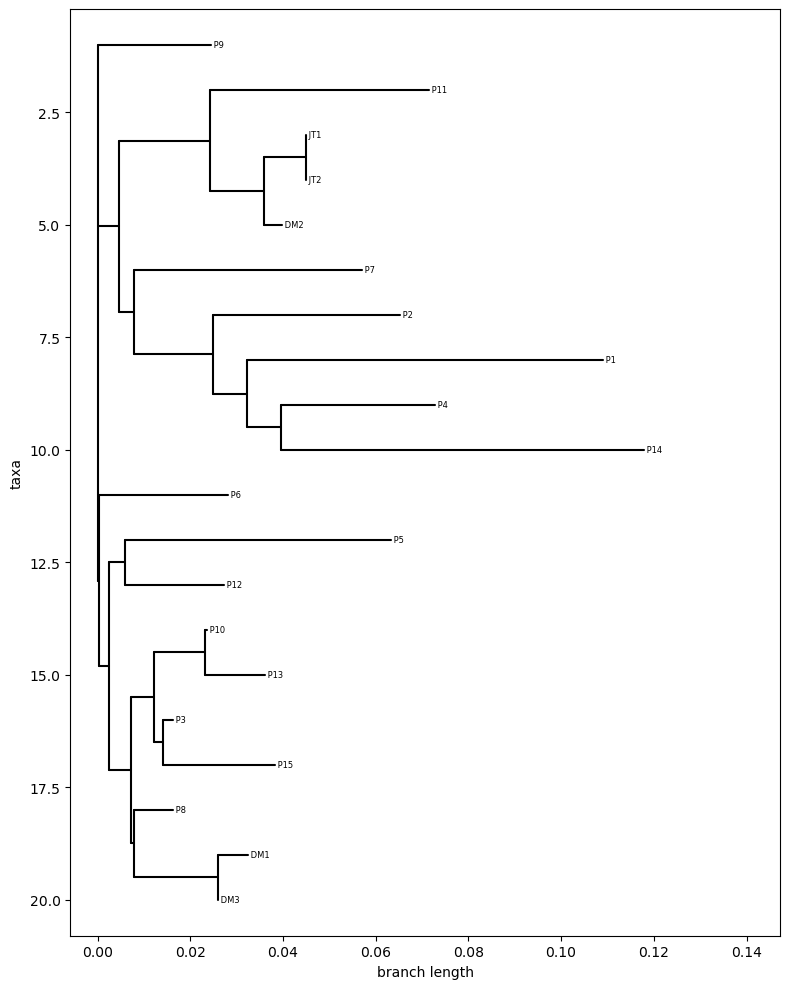

In [16]:
if __name__ == "__main__":
    # Read HIV RT sequences
    sequences = read_fasta("data/lafayette_SARS_RT.fasta")
    
    # Build distance matrix using Smith-Waterman
    dist_matrix, seq_ids = build_distance_matrix(sequences)
    seq_ids = list(seq_ids)
    
    # Generate unrooted tree using Neighbor-Joining
    tree = neighbor_joining(dist_matrix, seq_ids)
    
    # Plot tree
    plot_tree(tree)